# 🏦 Bati Bank Credit Risk — Exploratory Data Analysis
## Task 2: Understanding the Xente Transaction Dataset
---
**Analyst:** Your Name  
**Date:** May 2026  
**Dataset:** Xente eCommerce Transaction Data — Kaggle

---
### Purpose of This EDA

This notebook explores raw Xente transaction data to answer
four questions that guide all subsequent modeling:

1. What is the structure and quality of the data?
2. What behavioral patterns exist across customers?
3. What data problems need fixing before modeling?
4. What features will best predict credit risk?

### Key Context
Each row = one transaction. One customer = many rows.
There is **NO default label** — we engineer a proxy
target variable in Task 4 using RFM behavioral analysis.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


---
## 1. Data Overview

First look at structure, shape, types, and a sample
of rows to understand what we are working with.

In [43]:
# Load raw data
df = pd.read_csv('../data/raw/data.csv')

print("=" * 55)
print("DATASET SHAPE")
print("=" * 55)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 55)
print("COLUMN DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("FIRST 5 ROWS")
print("=" * 55)
df.head()

DATASET SHAPE
Rows:    95,662
Columns: 16

COLUMN DATA TYPES
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object

FIRST 5 ROWS


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.00,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.00,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.00,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.00,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.00,644,2018-11-15T03:34:21Z,2,0


In [44]:
# Read the data dictionary
definitions = pd.read_csv('../data/raw/Xente_Variable_Definitions.csv')
print("VARIABLE DEFINITIONS")
print("=" * 55)
print(definitions.to_string(index=False))

VARIABLE DEFINITIONS
         Column Name                                                                                                        Definition
       TransactionId                                                                        Unique �transaction identifier on platform
             BatchId                                                  Unique number assigned to a batch of transactions for processing
           AccountId                                                                Unique number identifying the customer on platform
      SubscriptionId                                                               Unique number identifying the customer subscription
          CustomerId                                                                             Unique identifier attached to Account
        CurrencyCode                                                                                                  Country currency
         CountryCode              

In [45]:
# Fix TransactionStartTime — stored as string, needs datetime
df['TransactionStartTime'] = pd.to_datetime(
    df['TransactionStartTime'], errors='coerce'
)

print("DATE COLUMN FIXED")
print("=" * 55)
print(f"dtype:      {df['TransactionStartTime'].dtype}")
print(f"Earliest:   {df['TransactionStartTime'].min()}")
print(f"Latest:     {df['TransactionStartTime'].max()}")
print(f"Days span:  "
      f"{(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days}")

print("\n" + "=" * 55)
print("QUICK PORTFOLIO FACTS")
print("=" * 55)
print(f"Unique customers:          {df['CustomerId'].nunique():,}")
print(f"Unique transactions:       {df['TransactionId'].nunique():,}")
print(f"Avg transactions/customer: {len(df)/df['CustomerId'].nunique():.1f}")
print(f"Fraud transactions:        {df['FraudResult'].sum():,} "
      f"({df['FraudResult'].mean():.2%})")
print(f"Positive amounts (debits): {(df['Amount'] > 0).sum():,} "
      f"({(df['Amount'] > 0).mean():.1%})")
print(f"Negative amounts (credits):{(df['Amount'] < 0).sum():,} "
      f"({(df['Amount'] < 0).mean():.1%})")

DATE COLUMN FIXED
dtype:      datetime64[ns, UTC]
Earliest:   2018-11-15 02:18:49+00:00
Latest:     2019-02-13 10:01:28+00:00
Days span:  90

QUICK PORTFOLIO FACTS
Unique customers:          3,742
Unique transactions:       95,662
Avg transactions/customer: 25.6
Fraud transactions:        193 (0.20%)
Positive amounts (debits): 57,473 (60.1%)
Negative amounts (credits):38,189 (39.9%)


---
## 2. Summary Statistics

Central tendency, dispersion, and shape of numerical
features. Extreme min/max values signal outliers.

In [46]:
print("NUMERICAL FEATURES — DESCRIPTIVE STATISTICS")
print("=" * 55)
df[['Amount', 'Value']].describe().round(2)

NUMERICAL FEATURES — DESCRIPTIVE STATISTICS


,Amount,Value
count,95662.00,95662.00
mean,6717.85,9900.58
std,123306.80,123122.09
min,-1000000.00,2.00
25%,-50.00,275.00
50%,1000.00,1000.00
75%,2800.00,5000.00
max,9880000.00,9880000.00


In [47]:
# Additional statistics not shown by .describe()
for col in ['Amount', 'Value']:
    data = df[col]
    skewness = data.skew()
    print(f"{col}:")
    print(f"  Skewness:  {skewness:.2f} "
          f"({'right-skewed' if skewness > 1 else 'left-skewed' if skewness < -1 else 'roughly normal'})")
    print(f"  Median:    {data.median():,.2f}")
    print(f"  Mean:      {data.mean():,.2f}")
    print(f"  Std Dev:   {data.std():,.2f}")
    print()

Amount:
  Skewness:  51.10 (right-skewed)
  Median:    1,000.00
  Mean:      6,717.85
  Std Dev:   123,306.80

Value:
  Skewness:  51.29 (right-skewed)
  Median:    1,000.00
  Mean:      9,900.58
  Std Dev:   123,122.09



---
## 3. Distribution of Numerical Features

Visualizing distribution shape to identify skewness,
bimodality, and outliers. Log transformation is shown
because financial amounts are almost always right-skewed.

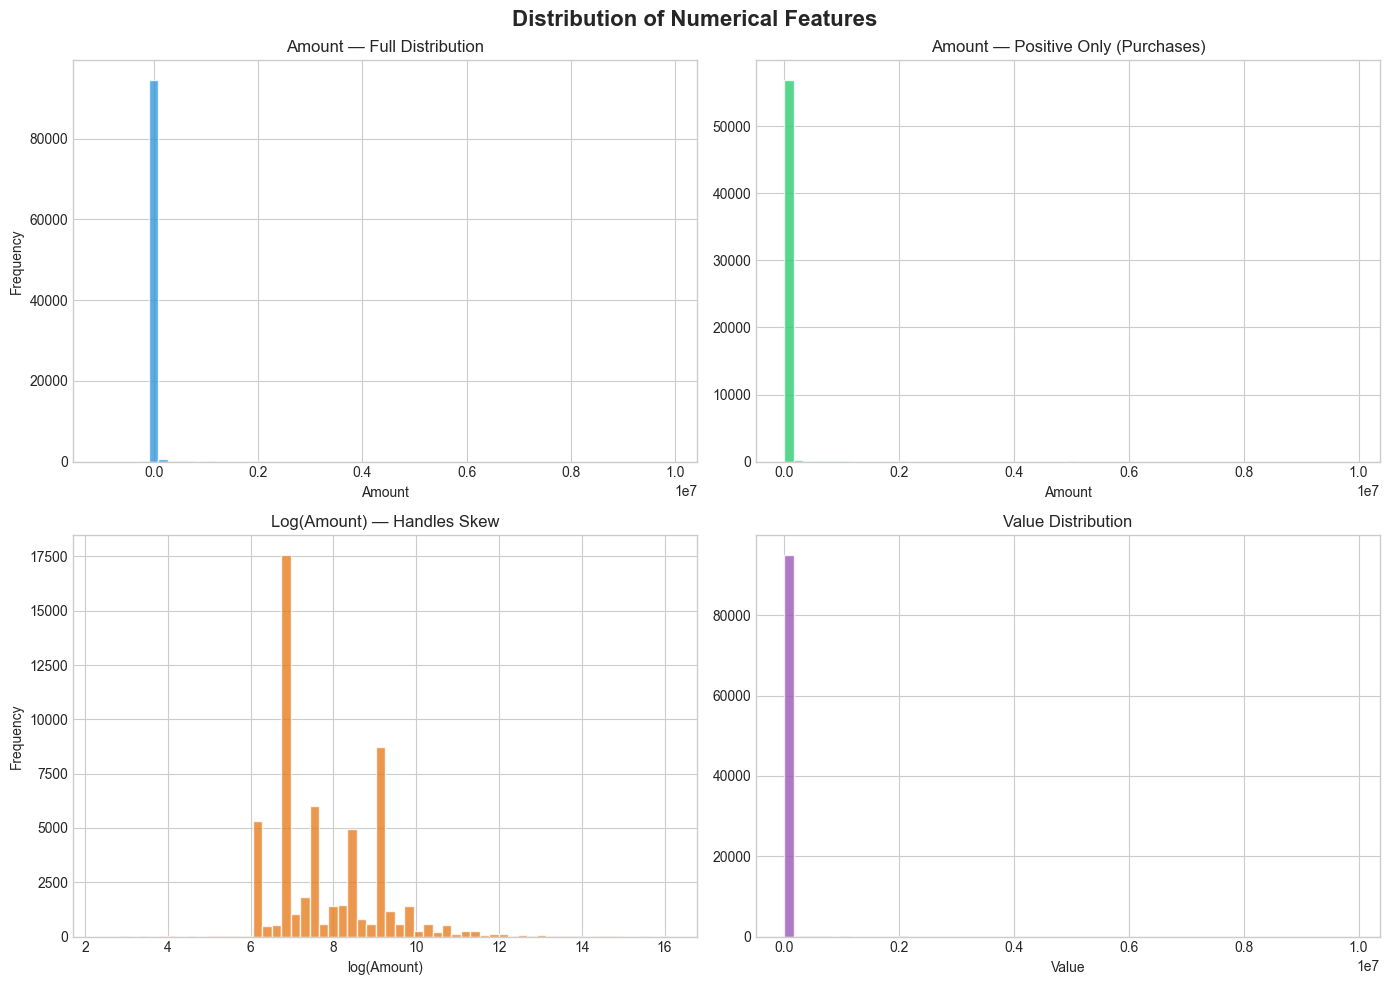

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Features',
             fontsize=16, fontweight='bold')

# All Amount values
axes[0, 0].hist(df['Amount'], bins=60,
                color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Amount — Full Distribution')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# Positive amounts only (actual purchases)
pos = df[df['Amount'] > 0]['Amount']
axes[0, 1].hist(pos, bins=60,
                color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Amount — Positive Only (Purchases)')
axes[0, 1].set_xlabel('Amount')

# Log transformed
axes[1, 0].hist(np.log1p(pos), bins=60,
                color='#e67e22', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Log(Amount) — Handles Skew')
axes[1, 0].set_xlabel('log(Amount)')
axes[1, 0].set_ylabel('Frequency')

# Value distribution
axes[1, 1].hist(df['Value'], bins=60,
                color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Value Distribution')
axes[1, 1].set_xlabel('Value')

plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Distribution of Categorical Features

Frequency of each category reveals dominant patterns
and rare categories needing special treatment.

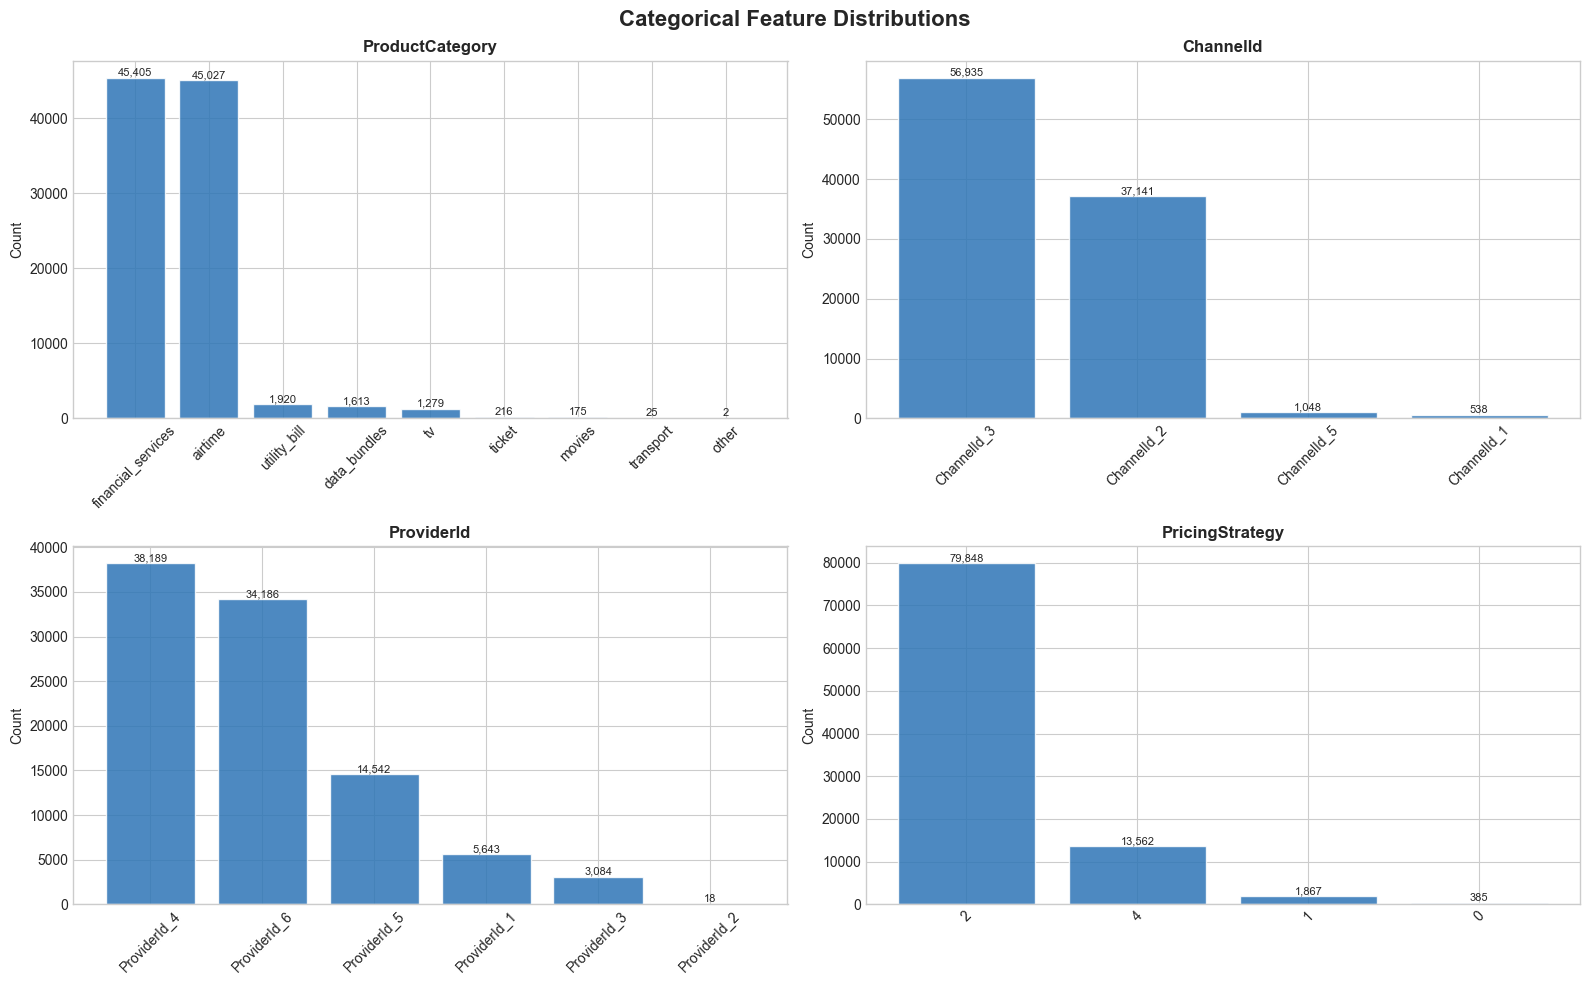

UNIQUE VALUES PER CATEGORICAL COLUMN
TransactionId                   95662 unique values
BatchId                         94809 unique values
AccountId                        3633 unique values
SubscriptionId                   3627 unique values
CustomerId                       3742 unique values
CurrencyCode                        1 unique values
ProviderId                          6 unique values
ProductId                          23 unique values
ProductCategory                     9 unique values
ChannelId                           4 unique values


In [49]:
cat_cols = ['ProductCategory', 'ChannelId',
            'ProviderId', 'PricingStrategy']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Categorical Feature Distributions',
             fontsize=16, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()

    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color='#2E75B6', alpha=0.85,
        edgecolor='white'
    )
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:,}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print unique counts
print("UNIQUE VALUES PER CATEGORICAL COLUMN")
print("=" * 40)
for col in df.select_dtypes(include='object').columns:
    print(f"{col:<30} {df[col].nunique():>6} unique values")

---
## 5. Correlation Analysis

Pairwise relationships between numerical features.
High correlation between Amount and Value is expected
since Value = |Amount|. Unexpected correlations
may indicate data issues or useful feature interactions.

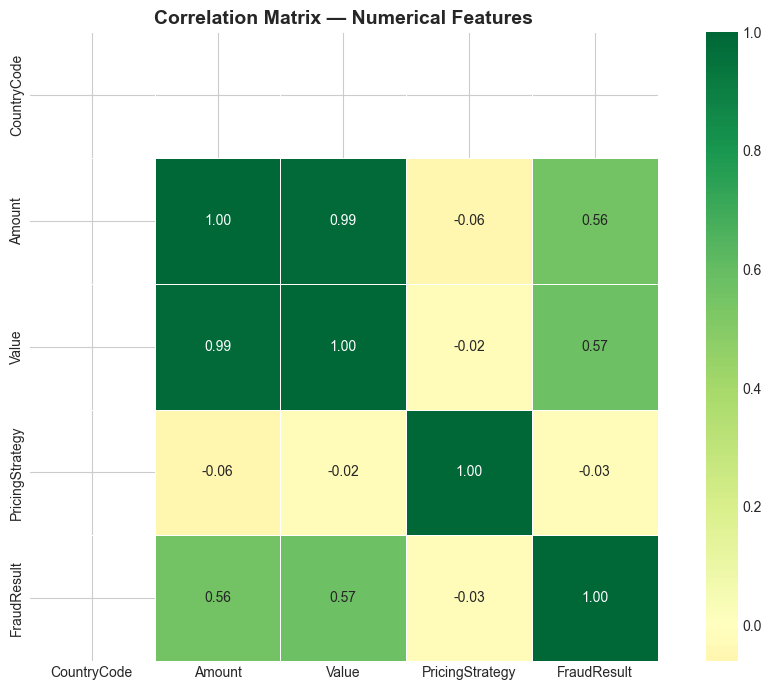

Correlation with FraudResult:
FraudResult        1.00
Value              0.57
Amount             0.56
PricingStrategy   -0.03
CountryCode         NaN
Name: FraudResult, dtype: float64


In [50]:
num_df = df.select_dtypes(include=[np.number])

corr_matrix = num_df.corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Numerical Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with FraudResult:")
print(corr_matrix['FraudResult'].sort_values(ascending=False))

---
## 6. Missing Values Analysis

Identifying data gaps and deciding on handling strategy
for each column before feature engineering.

In [51]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("MISSING VALUES ANALYSIS")
print("=" * 45)
print(missing_df.to_string())
print(f"\nColumns with missing data: {(missing > 0).sum()}")
print(f"Completely clean columns:  {(missing == 0).sum()}")

# Visualize only if there are missing values
if (missing > 0).any():
    cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(cols_with_missing.index,
            cols_with_missing['Missing %'],
            color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/missing_values.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n✅ No missing values in this dataset")

MISSING VALUES ANALYSIS
                      Missing Count  Missing %
TransactionId                     0       0.00
BatchId                           0       0.00
AccountId                         0       0.00
SubscriptionId                    0       0.00
CustomerId                        0       0.00
CurrencyCode                      0       0.00
CountryCode                       0       0.00
ProviderId                        0       0.00
ProductId                         0       0.00
ProductCategory                   0       0.00
ChannelId                         0       0.00
Amount                            0       0.00
Value                             0       0.00
TransactionStartTime              0       0.00
PricingStrategy                   0       0.00
FraudResult                       0       0.00

Columns with missing data: 0
Completely clean columns:  16

✅ No missing values in this dataset


---
## 7. Outlier Detection

Box plots identify extreme values that could distort
RFM calculations and model training. Outliers in
Amount are especially important since Monetary value
is a core RFM component.

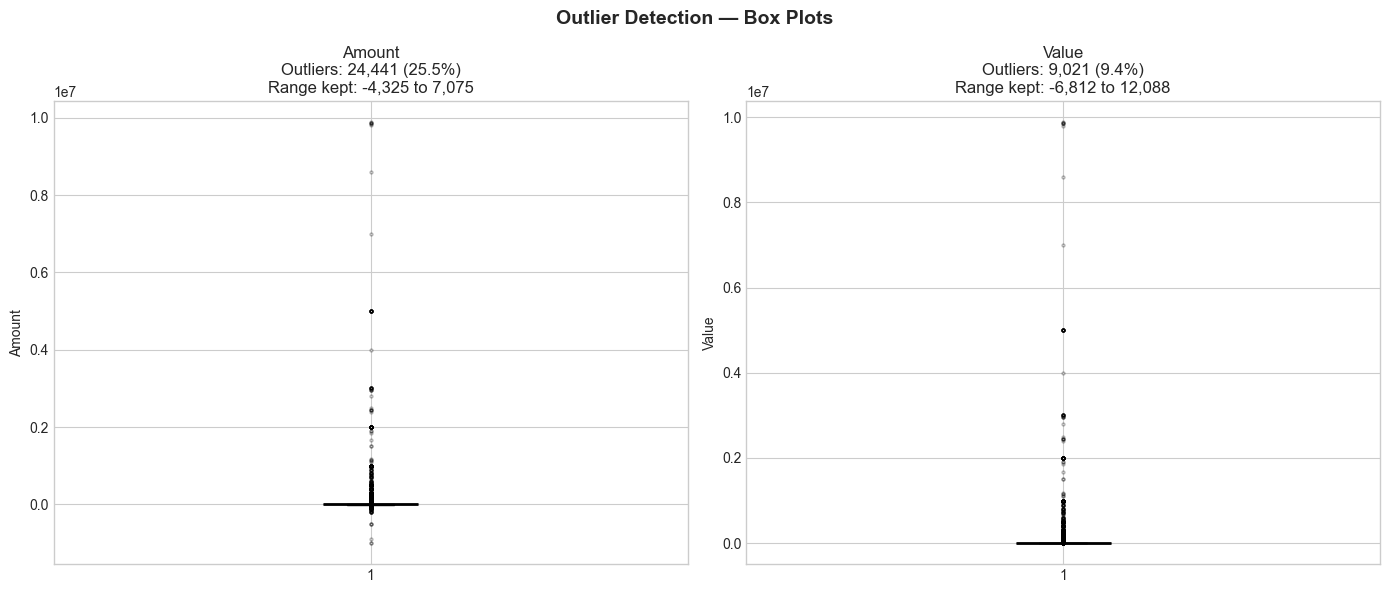

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Outlier Detection — Box Plots',
             fontsize=14, fontweight='bold')

for ax, col, color in zip(
    axes,
    ['Amount', 'Value'],
    ['#3498db', '#e74c3c']
):
    data = df[col].dropna()

    ax.boxplot(
        data,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2,
                        alpha=0.3, color=color)
    )

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()

    ax.set_title(
        f'{col}\n'
        f'Outliers: {n_out:,} ({n_out/len(data):.1%})\n'
        f'Range kept: {lower:,.0f} to {upper:,.0f}'
    )
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('../reports/outlier_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Customer Behavioral Patterns

Since Task 4 uses RFM analysis, understanding how
transactions are distributed across customers is
critical. High variation in frequency and monetary
value is what makes RFM segmentation meaningful.

CUSTOMER-LEVEL STATISTICS
       TransactionCount   TotalAmount  AvgAmount  TenureDays
count           3742.00       3742.00    3742.00     3742.00
mean              25.56     171737.74   15715.62       18.96
std               96.93    2717304.82  167699.10       26.87
min                1.00 -104900000.00 -425000.00        0.00
25%                2.00       4077.44    1000.00        0.00
50%                7.00      20000.00    2583.85        3.00
75%               20.00      79967.75    4877.61       32.00
max             4091.00   83451240.00 8601821.14       90.00


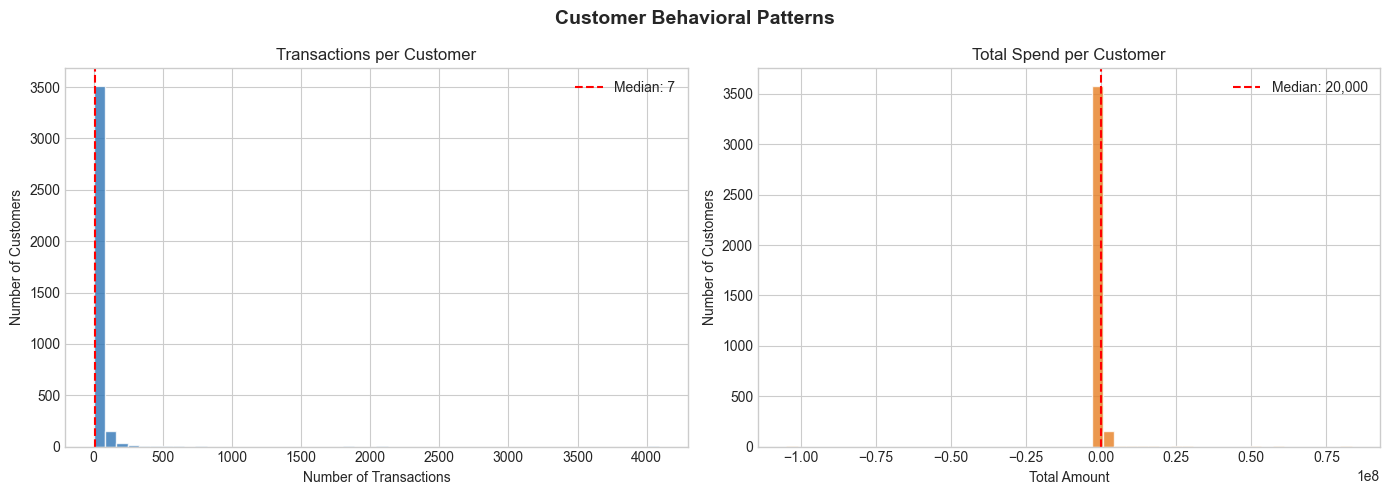

In [53]:
# Aggregate per customer
customer_stats = df.groupby('CustomerId').agg(
    TransactionCount = ('TransactionId', 'count'),
    TotalAmount      = ('Amount', 'sum'),
    AvgAmount        = ('Amount', 'mean'),
    LastTransaction  = ('TransactionStartTime', 'max'),
    FirstTransaction = ('TransactionStartTime', 'min'),
    UniqueProducts   = ('ProductCategory', 'nunique'),
    FraudCount       = ('FraudResult', 'sum')
).reset_index()

# Calculate customer tenure in days
customer_stats['TenureDays'] = (
    customer_stats['LastTransaction'] -
    customer_stats['FirstTransaction']
).dt.days

print("CUSTOMER-LEVEL STATISTICS")
print("=" * 55)
print(customer_stats[[
    'TransactionCount', 'TotalAmount',
    'AvgAmount', 'TenureDays'
]].describe().round(2))

# Plot transaction count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Behavioral Patterns',
             fontsize=14, fontweight='bold')

axes[0].hist(
    customer_stats['TransactionCount'],
    bins=50, color='#2E75B6',
    edgecolor='white', alpha=0.8
)
axes[0].set_title('Transactions per Customer')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(
    x=customer_stats['TransactionCount'].median(),
    color='red', linestyle='--',
    label=f"Median: {customer_stats['TransactionCount'].median():.0f}"
)
axes[0].legend()

axes[1].hist(
    customer_stats['TotalAmount'],
    bins=50, color='#e67e22',
    edgecolor='white', alpha=0.8
)
axes[1].set_title('Total Spend per Customer')
axes[1].set_xlabel('Total Amount')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(
    x=customer_stats['TotalAmount'].median(),
    color='red', linestyle='--',
    label=f"Median: {customer_stats['TotalAmount'].median():,.0f}"
)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/customer_behavior.png',
            dpi=150, bbox_inches='tight')
plt.show()

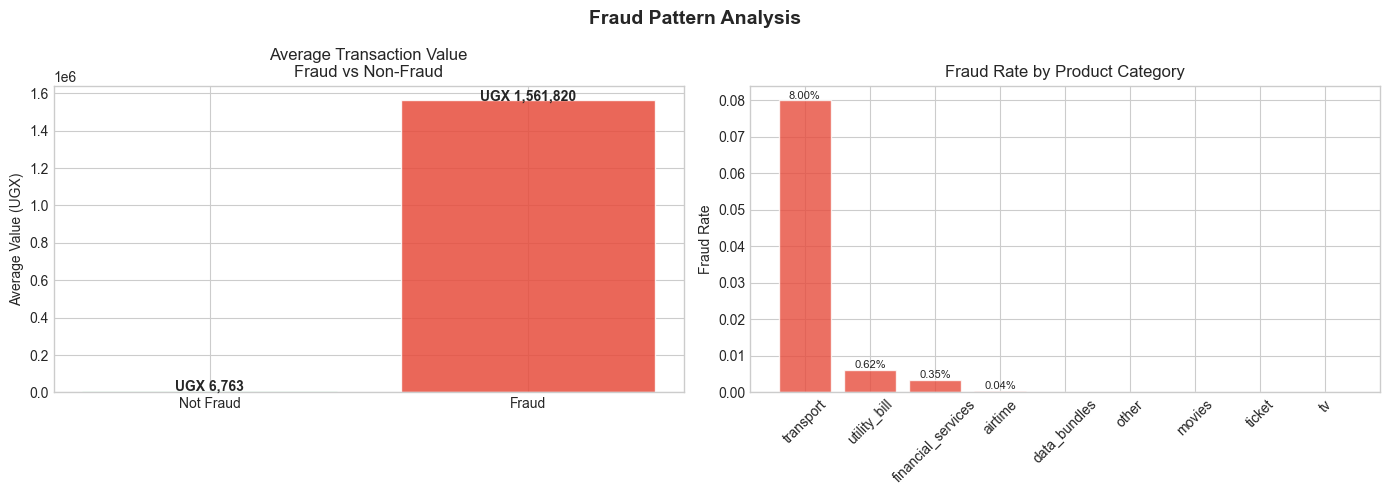

Average value — Fraud:     UGX 1,561,820
Average value — Non-fraud: UGX 6,763


In [54]:
# ─── Fraud vs Amount Analysis ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud Pattern Analysis', fontsize=14, fontweight='bold')

# Average transaction value: fraud vs non-fraud
fraud_stats = df.groupby('FraudResult').agg(
    AvgAmount  = ('Amount', 'mean'),
    AvgValue   = ('Value', 'mean'),
    Count      = ('TransactionId', 'count')
).reset_index()

fraud_stats['FraudLabel'] = fraud_stats['FraudResult'].map(
    {0: 'Not Fraud', 1: 'Fraud'}
)

axes[0].bar(
    fraud_stats['FraudLabel'],
    fraud_stats['AvgValue'],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', alpha=0.85
)
axes[0].set_title('Average Transaction Value\nFraud vs Non-Fraud')
axes[0].set_ylabel('Average Value (UGX)')

for i, (idx, row) in enumerate(fraud_stats.iterrows()):
    axes[0].text(
        i, row['AvgValue'] + 1000,
        f"UGX {row['AvgValue']:,.0f}",
        ha='center', fontweight='bold'
    )

# Fraud by product category
fraud_by_cat = df.groupby('ProductCategory').agg(
    Total = ('FraudResult', 'count'),
    Fraud = ('FraudResult', 'sum')
).reset_index()
fraud_by_cat['FraudRate'] = (
    fraud_by_cat['Fraud'] / fraud_by_cat['Total']
)
fraud_by_cat = fraud_by_cat.sort_values(
    'FraudRate', ascending=False
)

bars = axes[1].bar(
    fraud_by_cat['ProductCategory'],
    fraud_by_cat['FraudRate'],
    color='#e74c3c', alpha=0.8, edgecolor='white'
)
axes[1].set_title('Fraud Rate by Product Category')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(bars, fraud_by_cat['FraudRate']):
    if val > 0:
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.2%}',
            ha='center', fontsize=8
        )

plt.tight_layout()
plt.savefig('../reports/fraud_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Average value — Fraud:     UGX {fraud_stats[fraud_stats['FraudResult']==1]['AvgValue'].values[0]:,.0f}")
print(f"Average value — Non-fraud: UGX {fraud_stats[fraud_stats['FraudResult']==0]['AvgValue'].values[0]:,.0f}")

---
## 📋 Top Insights — EDA Summary

### Insight 1: Transaction-Level Data Requires Customer Aggregation
The dataset contains 95,662 rows across only 3,742 unique
customers — an average of 25.6 transactions per customer.
However, the distribution is extremely skewed: some customers
have 1 transaction while the most active has 4,091. All
modeling must first aggregate to customer level (one row per
customer) before training. This aggregation step is the
foundation of the entire feature engineering pipeline in Task 3.

### Insight 2: Extreme Right Skew Demands Log Transformation
Amount has a skewness of 51.10 — one of the most extreme
right skews possible. The median transaction is 1,000 UGX
but the mean is 6,718 UGX, pulled by transactions as large
as 9,880,000 UGX. Log transformation (log1p) is mandatory
before any distance-based modeling. Without it, a handful
of large transactions will dominate every calculation
including the RFM Monetary component.

### Insight 3: CountryCode Is Useless — Drop It
CountryCode has only 1 unique value (256 = Uganda) across
all 95,662 records. A column with zero variance provides
zero predictive signal and will be dropped in Task 3.
Similarly CurrencyCode has only 1 unique value (UGX).
Both columns are constants, not features.

### Insight 4: Fraud Correlates Strongly With Transaction Value
FraudResult correlates 0.57 with Value and 0.56 with Amount —
the strongest correlations in the entire dataset. High-value
transactions are significantly more likely to be fraudulent.
While fraud is not our direct credit risk target, this
pattern suggests that high monetary engagement is a
double-edged signal — it indicates both financial activity
AND elevated risk. This will inform how we interpret the
RFM Monetary dimension in Task 4.

### Insight 5: Zero Missing Values — But Extreme Outliers Exist
The dataset is completely clean — 0 missing values across all
16 columns. However, outliers are severe:
- Amount ranges from -1,000,000 to +9,880,000 UGX
- One customer has a total spend of -104,900,000 UGX
  (more refunds than purchases)
- Customer tenure ranges from 0 to 90 days
These outliers must be handled via capping or log
transformation before RFM and model training.

---
### Implications for Feature Engineering (Task 3)
- **Aggregate to customer level** — one row per CustomerId
- **Drop CountryCode and CurrencyCode** — zero variance
- **Drop Value** — redundant with Amount (correlation = ~1.0)
- **Log-transform Amount** — skewness of 51.10
- **Cap extreme outliers** — max transaction of 9.88M UGX
- **Extract time features** from TransactionStartTime:
  hour, day, month, day of week
- **Handle negative amounts** — 39.9% are credits/refunds,
  treat separately from purchases
- **FraudResult** — use as a feature, not target